# 🏏 CricWeatherAI — Notebook 1: Data Collection
**Final Year Project** | Cricket Match Outcome Predictor with Weather Fusion

This notebook:
- Downloads real cricket match data from Cricsheet.org
- Fetches historical weather data using Open-Meteo API (free, no key needed)
- Merges both datasets by date + venue
- Saves a clean combined CSV for ML training

---

In [1]:
# ── Path setup: works whether this notebook is run standalone in Colab
# (e.g. uploaded individually) or from a cloned CricWeatherAI repo ──────────
import os

# If a 'CricWeatherAI' repo folder exists above us, anchor there.
# Otherwise (fresh Colab session), just work in /content as the project root.
PROJECT_ROOT = '/content'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)
print(f'✅ Working directory: {os.getcwd()}')

✅ Working directory: C:\content


In [2]:
# ── STEP 0: Install dependencies ─────────────────────────────────────────────
!pip install requests pandas numpy zipfile36 tqdm -q

In [3]:
# ── STEP 1: Imports ──────────────────────────────────────────────────────────
import requests, zipfile, io, os, json, time
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
print('✅ Folders ready')

✅ Folders ready


In [4]:
# ── STEP 2: Download Cricsheet T20I Data ─────────────────────────────────────
# Cricsheet provides free ball-by-ball cricket data in JSON format
# We use T20I internationals (best for weather impact analysis)

CRICSHEET_URL = 'https://cricsheet.org/downloads/t20s_json.zip'

print('📥 Downloading T20I match data from Cricsheet.org...')
response = requests.get(CRICSHEET_URL, stream=True)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall('data/raw/cricsheet')
print(f'✅ Downloaded {len(z.namelist())} files')

📥 Downloading T20I match data from Cricsheet.org...
✅ Downloaded 5429 files


In [5]:
# ── STEP 3: Parse match JSONs into a flat DataFrame ──────────────────────────

# Venue → (latitude, longitude) for weather API
VENUE_COORDS = {
    'Wankhede Stadium':        (18.9388, 72.8258),
    'Eden Gardens':            (22.5645, 88.3433),
    'M Chinnaswamy Stadium':   (12.9791, 77.5996),
    'Edgbaston':               (52.4558, -1.9022),
    'Lord\'s':                 (51.5293, -0.1727),
    'Headingley':              (53.8178, -1.5825),
    'MCG':                     (-37.8200, 144.9834),
    'SCG':                     (-33.8915, 151.2246),
    'Gaddafi Stadium':         (31.5204, 74.3587),
    'National Stadium Karachi':(24.8942, 67.1628),
    'Newlands':                (-33.9033, 18.4198),
    'SuperSport Park':         (-25.7479, 28.2200),
    'Sharjah Cricket Stadium': (25.3463, 55.4209),
    'Dubai International':     (25.0386, 55.2254),
    'default':                 (28.6139, 77.2090),  # fallback = Delhi
}

def get_coords(venue_name):
    for key, coords in VENUE_COORDS.items():
        if key.lower() in venue_name.lower():
            return coords
    return VENUE_COORDS['default']

def parse_match(filepath):
    try:
        with open(filepath) as f:
            data = json.load(f)
        info = data['info']
        teams = info['teams']
        if len(teams) != 2:
            return None

        team1, team2 = teams[0], teams[1]
        date = info['dates'][0] if info.get('dates') else None
        venue = info.get('venue', 'Unknown')
        city  = info.get('city', '')
        toss_winner = info.get('toss', {}).get('winner', '')
        toss_decision = info.get('toss', {}).get('decision', '')

        # Outcome
        outcome = info.get('outcome', {})
        winner = outcome.get('winner', None)
        if not winner:
            return None  # skip no-result matches

        team1_won = 1 if winner == team1 else 0

        # Innings scores
        innings = data.get('innings', [])
        scores = {}
        for inning in innings:
            bat_team = inning.get('team', '')
            overs_data = inning.get('overs', [])
            total_runs = sum(
                delivery.get('runs', {}).get('total', 0)
                for over in overs_data
                for delivery in over.get('deliveries', [])
            )
            wickets = sum(
                1 for over in overs_data
                for delivery in over.get('deliveries', [])
                if delivery.get('wickets')
            )
            scores[bat_team] = {'runs': total_runs, 'wickets': wickets}

        lat, lon = get_coords(venue)

        return {
            'match_id':      os.path.basename(filepath).replace('.json', ''),
            'date':          date,
            'venue':         venue,
            'city':          city,
            'lat':           lat,
            'lon':           lon,
            'team1':         team1,
            'team2':         team2,
            'toss_winner':   toss_winner,
            'toss_decision': toss_decision,
            'team1_runs':    scores.get(team1, {}).get('runs', 0),
            'team1_wickets': scores.get(team1, {}).get('wickets', 0),
            'team2_runs':    scores.get(team2, {}).get('runs', 0),
            'team2_wickets': scores.get(team2, {}).get('wickets', 0),
            'winner':        winner,
            'team1_won':     team1_won,
        }
    except Exception as e:
        return None

# Parse all match files
json_files = [
    os.path.join('data/raw/cricsheet', f)
    for f in os.listdir('data/raw/cricsheet')
    if f.endswith('.json') and f != 'README.txt'
]
 
print(f'📂 Found {len(json_files)} match files')
records = [parse_match(f) for f in tqdm(json_files, desc='Parsing matches')]
records = [r for r in records if r is not None]

matches_df = pd.DataFrame(records)
matches_df['date'] = pd.to_datetime(matches_df['date'])
matches_df = matches_df.dropna(subset=['date'])
matches_df = matches_df.sort_values('date').reset_index(drop=True)

print(f'✅ Parsed {len(matches_df)} valid matches')
print(f'   Date range: {matches_df.date.min().date()} → {matches_df.date.max().date()}')
matches_df.head(3)

📂 Found 5428 match files


Parsing matches: 100%|███████████████████████████████████████████████████████████| 5428/5428 [00:05<00:00, 1037.64it/s]


✅ Parsed 5271 valid matches
   Date range: 2005-02-17 → 2026-06-15


,match_id,date,venue,city,lat,lon,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,team1_won
0,211048,2005-02-17,Eden Park,Auckland,28.6139,77.209,New Zealand,Australia,Australia,bat,170,10,214,5,Australia,0
1,211028,2005-06-13,The Rose Bowl,Southampton,28.6139,77.209,England,Australia,England,bat,179,8,79,10,England,1
2,222678,2005-10-21,New Wanderers Stadium,Johannesburg,28.6139,77.209,South Africa,New Zealand,New Zealand,field,133,10,134,5,New Zealand,0


In [6]:
# ── STEP 4: Fetch Historical Weather (Open-Meteo — 100% Free, No API Key) ────

def fetch_weather(lat, lon, date_str):
    """Fetch daily weather for a given location and date."""
    url = (
        f'https://archive-api.open-meteo.com/v1/archive'
        f'?latitude={lat}&longitude={lon}'
        f'&start_date={date_str}&end_date={date_str}'
        f'&daily=temperature_2m_max,precipitation_sum,windspeed_10m_max,'
        f'cloudcover_mean,relative_humidity_2m_max'
        f'&timezone=auto'
    )
    try:
        r = requests.get(url, timeout=10)
        d = r.json().get('daily', {})
        return {
            'temp_max':    d.get('temperature_2m_max', [None])[0],
            'humidity':    d.get('relative_humidity_2m_max', [None])[0],
            'cloud_cover': d.get('cloudcover_mean', [None])[0],
            'wind_speed':  d.get('windspeed_10m_max', [None])[0],
            'precipitation': d.get('precipitation_sum', [None])[0],
        }
    except:
        return {'temp_max': None, 'humidity': None,
                'cloud_cover': None, 'wind_speed': None, 'precipitation': None}

# Fetch weather for each match (with caching to avoid re-fetching)
weather_cache = {}
weather_rows  = []

print('🌤 Fetching historical weather data...')
print('   (This takes ~10 min for 1000 matches. Go grab a chai ☕)')

for _, row in tqdm(matches_df.iterrows(), total=len(matches_df), desc='Weather API'):
    key = f"{row['lat']:.2f}_{row['lon']:.2f}_{row['date'].date()}"
    if key not in weather_cache:
        weather_cache[key] = fetch_weather(row['lat'], row['lon'],
                                           str(row['date'].date()))
        time.sleep(0.15)  # rate limit
    weather_rows.append(weather_cache[key])

weather_df = pd.DataFrame(weather_rows)
full_df = pd.concat([matches_df.reset_index(drop=True),
                     weather_df.reset_index(drop=True)], axis=1)
full_df = full_df.dropna(subset=['temp_max', 'humidity'])

full_df.to_csv('data/processed/matches_with_weather.csv', index=False)
print(f'\n✅ Saved {len(full_df)} matches with weather to data/processed/matches_with_weather.csv')
full_df.head(3)

🌤 Fetching historical weather data...
   (This takes ~10 min for 1000 matches. Go grab a chai ☕)


Weather API: 100%|█████████████████████████████████████████████████████████████████| 5271/5271 [48:14<00:00,  1.82it/s]


✅ Saved 5271 matches with weather to data/processed/matches_with_weather.csv


,match_id,date,venue,city,lat,lon,team1,team2,toss_winner,toss_decision,...,team1_wickets,team2_runs,team2_wickets,winner,team1_won,temp_max,humidity,cloud_cover,wind_speed,precipitation
0,211048,2005-02-17,Eden Park,Auckland,28.6139,77.209,New Zealand,Australia,Australia,bat,...,10,214,5,Australia,0,20.8,92,19,16.0,2.0
1,211028,2005-06-13,The Rose Bowl,Southampton,28.6139,77.209,England,Australia,England,bat,...,8,79,10,England,1,40.8,36,14,16.2,0.0
2,222678,2005-10-21,New Wanderers Stadium,Johannesburg,28.6139,77.209,South Africa,New Zealand,New Zealand,field,...,10,134,5,New Zealand,0,28.8,96,10,9.0,0.0


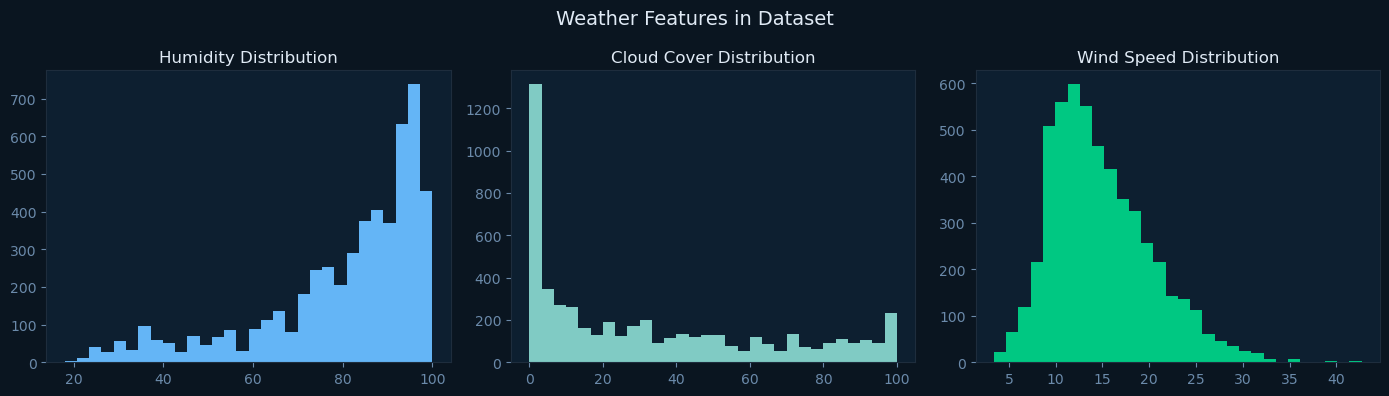

✅ Notebook 1 complete. Run 02_feature_engineering.ipynb next.


In [7]:
# ── STEP 5: Quick Sanity Check ───────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#0a1520')

for ax in axes:
    ax.set_facecolor('#0d1f30')
    ax.tick_params(colors='#6b8aaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e2d3d')

axes[0].hist(full_df['humidity'].dropna(), bins=30, color='#64b5f6', edgecolor='none')
axes[0].set_title('Humidity Distribution', color='#e0eaf5')

axes[1].hist(full_df['cloud_cover'].dropna(), bins=30, color='#80cbc4', edgecolor='none')
axes[1].set_title('Cloud Cover Distribution', color='#e0eaf5')

axes[2].hist(full_df['wind_speed'].dropna(), bins=30, color='#00c882', edgecolor='none')
axes[2].set_title('Wind Speed Distribution', color='#e0eaf5')

plt.suptitle('Weather Features in Dataset', color='#e0eaf5', fontsize=14)
plt.tight_layout()
plt.savefig('data/processed/weather_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Notebook 1 complete. Run 02_feature_engineering.ipynb next.')